# Bài Tập Cuối Kỳ — Phân Loại Tin Giả Tiếng Việt
## Chuẩn Bị Dữ Liệu: Thu Thập · Làm Sạch · Tiền Xử Lý · Xây Dựng Nhãn
## Tổng Quan Bài Toán

Notebook này trình bày toàn bộ pipeline **chuẩn bị dữ liệu** phục vụ bài toán **Phát Hiện Tin Giả (Fake News Detection)** — phân loại văn bản nhị phân giữa tin thật và tin giả trên ngữ liệu tiếng Việt. Bộ dữ liệu đầu ra được sử dụng trực tiếp để huấn luyện và đánh giá mô hình học máy trong giai đoạn cuối kỳ.

### Cấu Trúc Pipeline

| Phần | Nội Dung |
|------|----------|
| **0** | Cài đặt môi trường & nhập thư viện (bao gồm song song hóa CPU với `pandarallel`) |
| **1** | Thu thập dữ liệu — tải, xử lý và hợp nhất từ năm nguồn độc lập |
| **2** | Kiểm tra chất lượng & làm sạch dữ liệu thô (null, rỗng, trùng lặp, quá ngắn) |
| **2.3** | Phân tích khám phá dữ liệu (EDA) trên dữ liệu thô — phân phối lớp, độ dài, word cloud |
| **3** | Tiền xử lý văn bản tiếng Việt — chuẩn hóa Unicode, tách từ, loại từ dừng, lọc độ dài |
| **4** | Mã hóa nhãn (`is_fake` boolean → `label` số nguyên 0/1) |
| **5** | Phân tích khám phá dữ liệu (EDA) sau tiền xử lý — so sánh trước/sau xử lý |
| **6** | Kiểm tra chất lượng cuối & xuất bộ dữ liệu (full / train 80% / test 20%) |

### Các Nguồn Dữ Liệu Sử Dụng

| Nguồn | Nhãn | Nền tảng |
|-------|------|----------|
| Vietnamese Medical Fake News Dataset | Tin giả (y tế) | Kaggle |
| FakeNewsVN | Tin giả (đa chủ đề) | Kaggle |
| Vietnamese Fake-News-Dataset-PBL7 | Tin giả (đa chủ đề) | Kaggle |
| Việt Tân & Thời Báo (file Excel tùy chỉnh) | Tin giả (chính trị) | File cục bộ |
| VnExpress & Báo Nhân Dân (crawl) | Tin thật | File cục bộ |


---
## Phần 0 — Cài Đặt Môi Trường & Nhập Thư Viện

Cài đặt các thư viện cần thiết và cố định **hạt giống ngẫu nhiên toàn cục** (`RANDOM_SEED = 42`) nhằm đảm bảo **tính tái lập** (reproducibility) của toàn bộ pipeline.

> **Tối ưu tốc độ làm sạch dữ liệu:** Pipeline sử dụng thư viện `pandarallel` để song song hóa các phép biến đổi văn bản trên tất cả nhân CPU (thay vì chạy tuần tự mặc định của pandas). Thay vì viết `df['col'].apply(func)`, chỉ cần thay thành `df['col'].parallel_apply(func)` — tốc độ xử lý có thể tăng **4–8 lần** tùy số nhân CPU.


In [ ]:
%pip install kagglehub pyvi requests pandas matplotlib seaborn openpyxl regex scikit-learn scipy wordcloud datasets pandarallel -q


In [ ]:
import re
import regex
import random
import requests
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

from pandarallel import pandarallel
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Hạt giống tái lập ──────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Khởi tạo pandarallel — song song hóa trên toàn bộ nhân CPU ─────────────
pandarallel.initialize(progress_bar=True, verbose=1)

print(f"Hạt giống ngẫu nhiên toàn cục: {RANDOM_SEED}")
print("Thư viện đã sẵn sàng.")


Hạt giống ngẫu nhiên toàn cục: 42
Thư viện đã sẵn sàng.


---
## Phần 1 — Thu Thập & Hợp Nhất Dữ Liệu

Dữ liệu được thu thập từ **năm nguồn độc lập** nhằm tăng tính đa dạng về chủ đề và phong cách ngôn ngữ, đồng thời giảm thiểu **domain bias** (thiên lệch theo lĩnh vực).

> **Chiến lược cân bằng:** Tập tin giả y tế (Kaggle) được sử dụng toàn bộ để tối đa hóa dữ liệu huấn luyện. Tập tin thật được hợp nhất từ hai nguồn báo điện tử uy tín và loại bỏ trùng lặp.

### Các Nguồn Dữ Liệu Sử Dụng

| Nguồn | Nhãn | Nền tảng |
|-------|------|----------|
| Vietnamese Medical Fake News Dataset | Tin giả (y tế) | Kaggle |
| FakeNewsVN | Tin giả (đa chủ đề) | Kaggle |
| Vietnamese Fake-News-Dataset-PBL7 | Tin giả (đa chủ đề) | Kaggle |
| Việt Tân & Thời Báo (file Excel tùy chỉnh) | Tin giả (chính trị) | File cục bộ |
| VnExpress & Nhân Dân (crawl) | Tin thật | File cục bộ |


### 1.1 Nguồn 1 — Vietnamese Medical Fake News Dataset (Kaggle)

Dataset tin giả y tế tiếng Việt từ Kaggle (`leviettrieu369/vietnamese-medical-fake-news-dataset`). Chỉ giữ lại các bản ghi có nhãn `is_fake = True` (tin giả xác nhận).


In [ ]:
path   = kagglehub.dataset_download("leviettrieu369/vietnamese-medical-fake-news-dataset")
df_raw = pd.read_csv(f"{path}/full_dataset.csv")

df_fake_medical = df_raw[["title", "content", "is_fake"]].copy()
df_fake_medical = df_fake_medical[df_fake_medical["is_fake"] == True].reset_index(drop=True)

print(f"Fake news y tế (Kaggle): {len(df_fake_medical):,} bản ghi")

Using Colab cache for faster access to the 'vietnamese-medical-fake-news-dataset' dataset.
Fake news y tế (Kaggle): 4,925 bản ghi


### 1.2 Nguồn 2 — FakeNewsVN (Kaggle)

Dataset bao gồm các bài đăng Facebook đa chủ đề (`chuynvinquc/fakenewvn`). Do định dạng gốc không có cột `title` riêng, dòng đầu tiên không rỗng của `post_message` được trích xuất làm tiêu đề (tối đa 200 ký tự).

Bộ dữ liệu được hợp nhất từ hai file: `public_train.csv` và `warmup_training_dataset.xlsx`. Các bản ghi trùng lặp theo cột `content` được loại bỏ sau khi ghép.


In [ ]:
path_vn   = kagglehub.dataset_download("chuynvinquc/fakenewvn")
df_vn_raw = pd.read_csv(f"{path_vn}/public_train.csv")

df_vn = df_vn_raw[["post_message", "label"]].dropna(subset=["post_message"]).copy()
df_vn["post_message"] = df_vn["post_message"].astype(str).str.strip()

def extract_title(text: str) -> str:
    """Trích xuất dòng đầu tiên không rỗng làm tiêu đề (tối đa 200 ký tự)."""
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    return lines[0][:200] if len(lines) > 1 else text[:80]

df_vn["title"]   = df_vn["post_message"].apply(extract_title)
df_vn["content"] = df_vn["post_message"]
df_vn["is_fake"] = df_vn["label"].map({0: False, 1: True})

df_fake_vn = df_vn[df_vn["is_fake"] == True][["title", "content", "is_fake"]].reset_index(drop=True)

print(f"Fake news FakeNewsVN (public_train): {len(df_fake_vn):,} bản ghi")

# ── Bổ sung từ warmup_training_dataset.xlsx ────────────────────────────────
df_vn_warmup_raw = pd.read_excel(f"{path_vn}/warmup_training_dataset.xlsx", sheet_name=0)
df_vn_warmup = df_vn_warmup_raw[["post_message", "label"]].dropna(subset=["post_message"]).copy()
df_vn_warmup["post_message"] = df_vn_warmup["post_message"].astype(str).str.strip()
df_vn_warmup["title"]   = df_vn_warmup["post_message"].apply(extract_title)
df_vn_warmup["content"] = df_vn_warmup["post_message"]
df_vn_warmup["is_fake"] = df_vn_warmup["label"].map({0: False, 1: True})

df_vn_warmup_fake = df_vn_warmup[df_vn_warmup["is_fake"] == True][["title", "content", "is_fake"]].reset_index(drop=True)

# Gộp lại, loại trùng lặp
df_fake_vn = pd.concat([df_fake_vn, df_vn_warmup_fake], ignore_index=True)
df_fake_vn = df_fake_vn.drop_duplicates(subset=["content"]).reset_index(drop=True)

print(f"Fake news FakeNewsVN (sau warmup)  : {len(df_fake_vn):,} bản ghi")

Using Colab cache for faster access to the 'fakenewvn' dataset.
Fake news FakeNewsVN (public_train): 734 bản ghi
Fake news FakeNewsVN (sau warmup)  : 820 bản ghi


### 1.3 Nguồn 3 — Vietnamese Fake News Dataset PBL7 (Kaggle)

Dataset tin giả tiếng Việt đa chủ đề từ Kaggle (`goumanguyen/vietnamese-fake-news-dataset-pbl7`). Sử dụng file `update_train_data.csv`, chỉ giữ các bản ghi có `Label == 1` (tin giả). Các bản ghi có nội dung ít hơn 10 từ được loại bỏ ngay tại nguồn để đảm bảo chất lượng đầu vào.


In [ ]:
path_pbl7 = kagglehub.dataset_download("goumanguyen/vietnamese-fake-news-dataset-pbl7")
df_pbl7_raw = pd.read_csv(
    f"{path_pbl7}/last_data/update_data/update_train_data.csv"
)

print("Phân phối nhãn:")
print(df_pbl7_raw["Label"].value_counts())

# Chỉ giữ tin giả (Label == 1)
df_pbl7 = df_pbl7_raw[df_pbl7_raw["Label"] == 1][["Maintext"]].copy()
df_pbl7 = df_pbl7.rename(columns={"Maintext": "content"})
df_pbl7["content"] = df_pbl7["content"].astype(str).str.strip()

# Trích dòng đầu làm title (tái dùng hàm extract_title đã định nghĩa ở 1.2)
df_pbl7["title"]   = df_pbl7["content"].apply(extract_title)
df_pbl7["is_fake"] = True
df_pbl7 = df_pbl7[["title", "content", "is_fake"]].dropna().reset_index(drop=True)

# Lọc bản ghi quá ngắn (< 10 từ) ngay tại nguồn
df_pbl7 = df_pbl7[df_pbl7["content"].str.split().str.len() >= 10].reset_index(drop=True)

print(f"\nFake news PBL7 (sau lọc): {len(df_pbl7):,} bản ghi")
print("\nMẫu bản ghi đầu tiên:")
print(df_pbl7["content"].iloc[0][:200])

Using Colab cache for faster access to the 'vietnamese-fake-news-dataset-pbl7' dataset.
Phân phối nhãn:
Label
0    472
1    377
Name: count, dtype: int64

Fake news PBL7 (sau lọc): 375 bản ghi

Mẫu bản ghi đầu tiên:
S.T.T.D Tưởng Năng Tiến () - Dư luận, trong cũng như ngoài nước, cứ tha hồ mà dậy sóng. Sóng gió trong những tách nước trà nào có ảnh hưởng chi nhiều. Giới lãnh đạo CSVN (chắ


In [ ]:
import pandas as pd # Ensure pandas is imported

def extract_title(text: str) -> str:
    """Trích xuất dòng đầu tiên không rỗng làm tiêu đề (tối đa 200 ký tự)."""
    lines = [l.strip() for l in text.split("\n") if l.strip()]
    return lines[0][:200] if len(lines) > 1 else text[:80]

def load_and_process_fake_excel(file_path: str, source_name: str) -> pd.DataFrame:
    """Loads and processes a fake news Excel file."""
    try:
        df_raw_source = pd.read_excel(file_path)
    except FileNotFoundError:
        print(f"Cảnh báo: Tệp '{file_path}' không tìm thấy. Bỏ qua nguồn này.")
        return pd.DataFrame(columns=["title", "content", "is_fake"])

    df_source = df_raw_source.copy()
    df_source.rename(columns={
        'Title': 'title',
        'Content': 'content',
        'Maintext': 'content',
        'post_message': 'content',
        'Tiêu đề': 'title',
        'Nội dung': 'content'
    }, inplace=True)

    # Ensure 'content' and 'title' columns exist
    if 'content' not in df_source.columns and 'title' not in df_source.columns:
        print(f"Cảnh báo: '{file_path}' không chứa cột 'title' hoặc 'content'. Bỏ qua dữ liệu này.")
        return pd.DataFrame(columns=["title", "content", "is_fake"])

    if 'content' in df_source.columns:
        df_source["content"] = df_source["content"].astype(str).str.strip()
        if 'title' not in df_source.columns:
            df_source["title"] = df_source["content"].apply(extract_title)
    elif 'title' in df_source.columns: # Fallback if only 'title' is present
        df_source["title"] = df_source["title"].astype(str).str.strip()
        df_source["content"] = df_source["title"] # Use title as content
    else: # Should not happen if previous checks are robust, but for safety
        df_source["title"] = ""
        df_source["content"] = ""

    df_source["is_fake"] = True
    df_source = df_source[["title", "content", "is_fake"]].dropna().reset_index(drop=True)
    df_source = df_source[df_source["content"].str.split().str.len() >= 10].reset_index(drop=True)

    print(f"Fake news {source_name}: {len(df_source):,} bản ghi")
    return df_source

# === NGUỒN MỚI: Tin Giả Việt Tân (viettan_fake.xlsx) và Thời Báo (thoibao_fake.xlsx) ===
df_viettan_fake = load_and_process_fake_excel("viettan_fake.xlsx", "Việt Tân")
df_thoibao_fake = load_and_process_fake_excel("thoibao_fake.xlsx", "Thời Báo")

# Combine all fake news from custom Excel sources
df_fake_custom_excels = pd.concat([df_viettan_fake, df_thoibao_fake], ignore_index=True)
df_fake_custom_excels = df_fake_custom_excels.drop_duplicates(subset=["content"]).reset_index(drop=True)

print(f"\nTổng tin giả từ nguồn Excel tùy chỉnh (Việt Tân, Thời Báo): {len(df_fake_custom_excels):,} bản ghi")

Fake news Việt Tân: 6,123 bản ghi
Fake news Thời Báo: 3,466 bản ghi

Tổng tin giả từ nguồn Excel tùy chỉnh (Việt Tân, Thời Báo): 9,583 bản ghi


### 1.4 Nguồn 4 — Tin Giả Tùy Chỉnh (Việt Tân & Thời Báo)

Hai tệp Excel cục bộ (`viettan_fake.xlsx`, `thoibao_fake.xlsx`) chứa các bài viết từ các nguồn bị đánh giá là thiếu tin cậy hoặc có xu hướng tuyên truyền. Hàm `load_and_process_fake_excel` được sử dụng để chuẩn hóa định dạng cột và lọc bản ghi quá ngắn.


In [ ]:
# === CẬP NHẬT: Nguồn 4 — Tin Thật (VnExpress & Nhân Dân) ===
# Load from vn_express_true.xlsx
df_vn_express_true = pd.read_excel("vn_express_true.xlsx", usecols=["title", "content"])
df_vn_express_true["is_fake"] = False
df_vn_express_true = df_vn_express_true.dropna(subset=["title", "content"])
print(f"Tin thật VnExpress: {len(df_vn_express_true):,} bản ghi")

# Load from nhandan_true.csv
df_nhandan_true = pd.read_csv("nhandan_true.csv", usecols=["title", "content"])
df_nhandan_true["is_fake"] = False
df_nhandan_true = df_nhandan_true.dropna(subset=["title", "content"])
print(f"Tin thật Nhân Dân: {len(df_nhandan_true):,} bản ghi")

# Combine all true news
df_true = pd.concat([df_vn_express_true, df_nhandan_true], ignore_index=True)
df_true = df_true.drop_duplicates(subset=["content"]).reset_index(drop=True)
print(f"Tổng tin thật sau hợp nhất: {len(df_true):,} bản ghi")

Tin thật VnExpress: 6,733 bản ghi
Tin thật Nhân Dân: 34,029 bản ghi
Tổng tin thật sau hợp nhất: 39,426 bản ghi


### 1.5 Nguồn 5 — Tin Thật (VnExpress & Nhân Dân)

Tin thật được thu thập qua crawling từ hai tờ báo điện tử uy tín:
- **VnExpress** — lưu tại `vn_express_true.xlsx`
- **Báo Nhân Dân** — lưu tại `nhandan_true.csv`

Sau khi hợp nhất, các bản ghi trùng lặp theo cột `content` được loại bỏ để đảm bảo mỗi bài báo chỉ xuất hiện một lần trong tập dữ liệu.


In [ ]:
# Lấy mẫu có kiểm soát để cân bằng chủ đề
df_fake_medical_s = df_fake_medical.copy() # Loại bỏ giới hạn số lượng theo yêu cầu trước đó
# Hợp nhất toàn bộ nguồn
df_raw = pd.concat([
    df_fake_medical_s[["title", "content", "is_fake"]],
    df_fake_vn[["title",       "content", "is_fake"]],
    df_pbl7[["title",          "content", "is_fake"]],
    df_fake_custom_excels[["title",  "content", "is_fake"]], # Sử dụng df_fake_custom_excels
    df_true[["title",        "content", "is_fake"]],
], ignore_index=True)
n_fake_total = len(df_fake_medical_s) + len(df_fake_vn) + len(df_pbl7) + len(df_fake_custom_excels) # Cập nhật tổng số tin giả

print("=" * 58)
print("          TÓM TẮT HỢP NHẤT BỘ DỮ LIỆU")
print("=" * 58)
print(f"  Fake news y tế  (Kaggle)     : {len(df_fake_medical_s):>6,}  (trích từ {len(df_fake_medical):,})")
print(f"  Fake news FakeNewsVN         : {len(df_fake_vn):>6,}  (toàn bộ)")
print(f"  Fake news ViFactCheck        : {len(df_pbl7):>6,}  (toàn bộ)")
print(f"  Fake news Excel tùy chỉnh    : {len(df_fake_custom_excels):>6,}  (toàn bộ)") # Cập nhật mô tả
print(f"  Tin thật (Tổng hợp)         : {len(df_true):>6,} ") # Thay đổi mô tả
print("-" * 58)
print(f"  Tổng cộng                    : {len(df_raw):>6,}")
print(f"  Tổng tin giả                 : {n_fake_total:,}")
print(f"  Tổng tin thật                : {len(df_true):,}")
print(f"  Tỷ lệ fake/true              : 1 : {len(df_true)/n_fake_total:.2f}")
print("=" * 58)
print("\nPhân phối nhãn:")
print(df_raw["is_fake"].value_counts())

          TÓM TẮT HỢP NHẤT BỘ DỮ LIỆU
  Fake news y tế  (Kaggle)     :  4,925  (trích từ 4,925)
  Fake news FakeNewsVN         :    820  (toàn bộ)
  Fake news ViFactCheck        :    375  (toàn bộ)
  Fake news Excel tùy chỉnh    :  9,583  (toàn bộ)
  Tin thật (Tổng hợp)         : 39,426 
----------------------------------------------------------
  Tổng cộng                    : 55,129
  Tổng tin giả                 : 15,703
  Tổng tin thật                : 39,426
  Tỷ lệ fake/true              : 1 : 2.51

Phân phối nhãn:
is_fake
False    39426
True     15703
Name: count, dtype: int64


---
## Phần 2 — Kiểm Tra Chất Lượng & Làm Sạch Dữ Liệu Thô

Trước khi tiến hành bất kỳ biến đổi văn bản nào, pipeline thực hiện kiểm tra chất lượng có hệ thống theo bốn tiêu chí, theo thứ tự ưu tiên:

| Thứ tự | Vấn đề | Xử lý |
|--------|--------|-------|
| 1 | **Giá trị null** | Xóa hàng thiếu `title`, `content`, hoặc `is_fake` |
| 2 | **Chuỗi rỗng** | Xóa hàng có `title` hoặc `content` sau khi strip là chuỗi rỗng |
| 3 | **Trùng lặp** | Xóa hàng có `content` trùng nhau hoàn toàn |
| 4 | **Quá ngắn** | Loại bỏ bản ghi có ít hơn 10 từ trong `content` |


### 2.1 Kiểm Tra Chất Lượng Dữ Liệu Thô


In [ ]:
df = df_raw[["title", "content", "is_fake"]].copy()

# 1. Giá trị null
print("=== 1. Kiểm tra giá trị null ===")
print(df.isnull().sum())
df = df.dropna(subset=["title", "content", "is_fake"])

# 2. Chuỗi rỗng
empty_title   = df["title"].str.strip().eq("").sum()
empty_content = df["content"].str.strip().eq("").sum()
print(f"\n=== 2. Chuỗi rỗng ===")
print(f"  Tiêu đề rỗng : {empty_title}")
print(f"  Nội dung rỗng: {empty_content}")
df = df[df["title"].str.strip() != ""]
df = df[df["content"].str.strip() != ""]

# 3. Trùng lặp
before_dedup = len(df)
df = df.drop_duplicates(subset=["content"])
print(f"\n=== 3. Trùng lặp ===")
print(f"  Đã xóa: {before_dedup - len(df)} hàng → còn lại: {len(df)}")

# 4. Lọc độ dài thô
content_len = df["content"].str.split().str.len()
df = df[content_len >= 10].reset_index(drop=True)
print(f"\n=== 4. Lọc độ dài thô (≥ 10 từ) ===")
print(f"  Bản ghi còn lại: {len(df)}")


=== 1. Kiểm tra giá trị null ===
title      0
content    0
is_fake    0
dtype: int64

=== 2. Chuỗi rỗng ===
  Tiêu đề rỗng : 0
  Nội dung rỗng: 0

=== 3. Trùng lặp ===
  Đã xóa: 2 hàng → còn lại: 55127

=== 4. Lọc độ dài thô (≥ 10 từ) ===
  Bản ghi còn lại: 54946


### 2.2 Thống Kê Mô Tả Bộ Dữ Liệu Thô

Báo cáo thống kê mô tả cơ bản kèm kiểm định **Mann-Whitney U** để đánh giá sự khác biệt về độ dài nội dung giữa hai lớp (tin thật vs. tin giả).


In [ ]:
from scipy import stats

content_lengths = df["content"].str.split().str.len()
label_counts    = df["is_fake"].value_counts()
n_real          = label_counts.get(False, 0)
n_fake          = label_counts.get(True,  0)
imbalance_ratio = max(n_real, n_fake) / min(n_real, n_fake)

len_real = df.loc[df["is_fake"] == False, "content"].str.split().str.len()
len_fake = df.loc[df["is_fake"] == True,  "content"].str.split().str.len()
u_stat, p_val = stats.mannwhitneyu(len_real, len_fake, alternative="two-sided")
r_effect = 1 - 2 * u_stat / (len(len_real) * len(len_fake))

print("=" * 58)
print("        THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU THÔ")
print("=" * 58)
print(f"  Tổng bản ghi          : {len(df):,}")
print(f"  Tin thật (label=0)    : {n_real:,}  ({n_real/len(df)*100:.1f}%)")
print(f"  Tin giả  (label=1)    : {n_fake:,}  ({n_fake/len(df)*100:.1f}%)")
print(f"  Tỷ lệ mất cân bằng    : {imbalance_ratio:.2f}x")
print("-" * 58)
print(f"  Độ dài content (từ) — Toàn bộ:")
print(f"    Mean={content_lengths.mean():.1f}  |  Median={content_lengths.median():.0f}")
print(f"    Min={content_lengths.min()}         |  Max={content_lengths.max()}")
print(f"  Độ dài content (từ) — Theo nhãn:")
print(f"    Tin thật : mean={len_real.mean():.1f}, median={len_real.median():.0f}")
print(f"    Tin giả  : mean={len_fake.mean():.1f}, median={len_fake.median():.0f}")
print("-" * 58)
pstar = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
print(f"  Mann-Whitney U test   : p = {p_val:.2e}  ({pstar})")
print(f"  Rank-biserial r       : {abs(r_effect):.4f}  ",
      "(Lớn)" if abs(r_effect) >= 0.5 else "(Vừa)" if abs(r_effect) >= 0.3 else "(Nhỏ)")
print("=" * 58)


        THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU THÔ
  Tổng bản ghi          : 54,946
  Tin thật (label=0)    : 39,250  (71.4%)
  Tin giả  (label=1)    : 15,696  (28.6%)
  Tỷ lệ mất cân bằng    : 2.50x
----------------------------------------------------------
  Độ dài content (từ) — Toàn bộ:
    Mean=789.6  |  Median=637
    Min=10         |  Max=48315
  Độ dài content (từ) — Theo nhãn:
    Tin thật : mean=730.7, median=604
    Tin giả  : mean=936.8, median=777
----------------------------------------------------------
  Mann-Whitney U test   : p = 5.76e-139  (***)
  Rank-biserial r       : 0.1368   (Nhỏ)


---
## Phần 2.3 — Phân Tích Khám Phá Dữ Liệu (EDA) Thô

Phần này trực quan hóa bộ dữ liệu **thô** (`df`) sau bước làm sạch ban đầu (Phần 2.1), trước khi áp dụng các kỹ thuật tiền xử lý văn bản chuyên sâu. Mục đích là kiểm tra tính toàn vẹn và đặc điểm phân phối của dữ liệu ngay từ giai đoạn đầu pipeline.


### 2.3.1 Phân Phối Lớp Thô

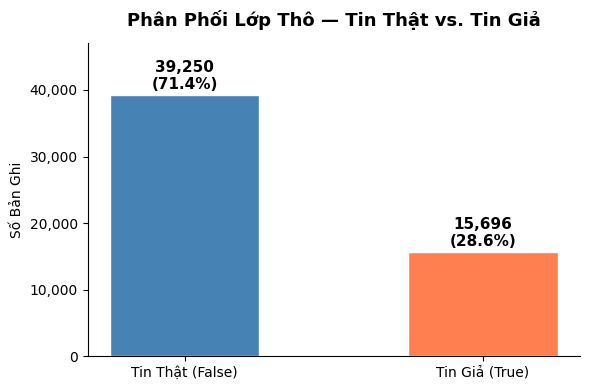

In [ ]:
label_counts_raw = df["is_fake"].value_counts().sort_index()
labels_raw       = ["Tin Thật (False)", "Tin Giả (True)"]
colors_raw       = ["steelblue", "coral"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels_raw, label_counts_raw.values, color=colors_raw, edgecolor="white", width=0.5)

for bar, count in zip(bars, label_counts_raw.values):
    pct = count / label_counts_raw.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts_raw.max() * 0.01,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Phân Phối Lớp Thô — Tin Thật vs. Tin Giả", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Số Bản Ghi")
ax.set_ylim(0, label_counts_raw.max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_raw_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3.2 Phân Phối Độ Dài Nội Dung Thô

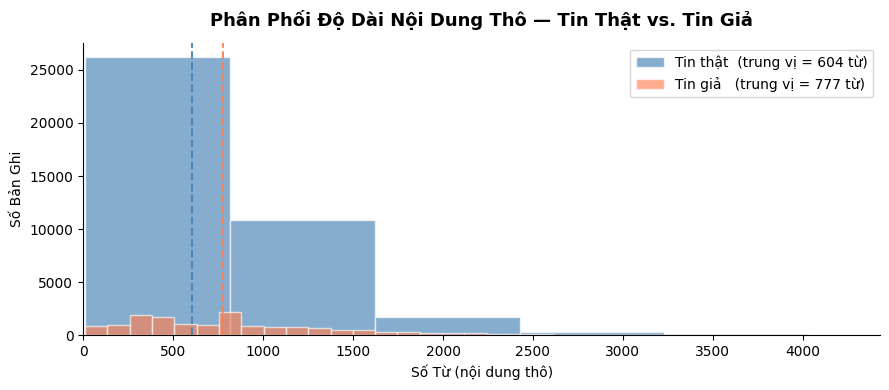

In [ ]:
len_real_raw = df.loc[df["is_fake"] == False, "content"].str.split().str.len()
len_fake_raw = df.loc[df["is_fake"] == True,  "content"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(len_real_raw, bins=60, alpha=0.65, color="steelblue", edgecolor="white",
        label=f"Tin thật  (trung vị = {len_real_raw.median():.0f} từ)")
ax.hist(len_fake_raw, bins=60, alpha=0.65, color="coral",     edgecolor="white",
        label=f"Tin giả   (trung vị = {len_fake_raw.median():.0f} từ)")

ax.axvline(len_real_raw.median(), color="steelblue", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axvline(len_fake_raw.median(), color="coral",     linestyle="--", linewidth=1.5, alpha=0.9)

ax.set_title("Phân Phối Độ Dài Nội Dung Thô — Tin Thật vs. Tin Giả", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Số Từ (nội dung thô)")
ax.set_ylabel("Số Bản Ghi")
ax.legend(fontsize=10)
ax.set_xlim(0, max(len_real_raw.quantile(0.99), len_fake_raw.quantile(0.99)) * 1.05)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_raw_02_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3.3 Boxplot Độ Dài Nội Dung Thô — Phân Tích Phân Phối & Outlier

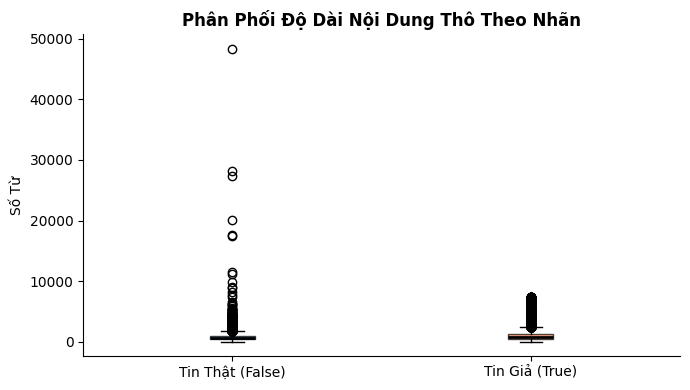

In [ ]:
df["content_token_count_raw"] = df["content"].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4))

data_true_raw = df.loc[df["is_fake"] == False, "content_token_count_raw"]
data_fake_raw = df.loc[df["is_fake"] == True,  "content_token_count_raw"]

bp = ax.boxplot(
    [data_true_raw, data_fake_raw],
    labels=["Tin Thật (False)", "Tin Giả (True)"],
    patch_artist=True,
    notch=False,
    medianprops=dict(color="black", linewidth=2)
)
bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("coral");     bp["boxes"][1].set_alpha(0.7)

ax.set_title("Phân Phối Độ Dài Nội Dung Thô Theo Nhãn", fontsize=12, fontweight="bold")
ax.set_ylabel("Số Từ")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_raw_03_boxplot_length.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3.4 Word Cloud Theo Nhãn (Thô)

Word cloud trực quan hóa các từ đặc trưng cho mỗi nhãn trong dữ liệu thô. So sánh hai cloud giúp phát hiện **data leakage tiềm ẩn** — khi một từ chủ đề (domain-specific) xuất hiện gần như chỉ trong một lớp.

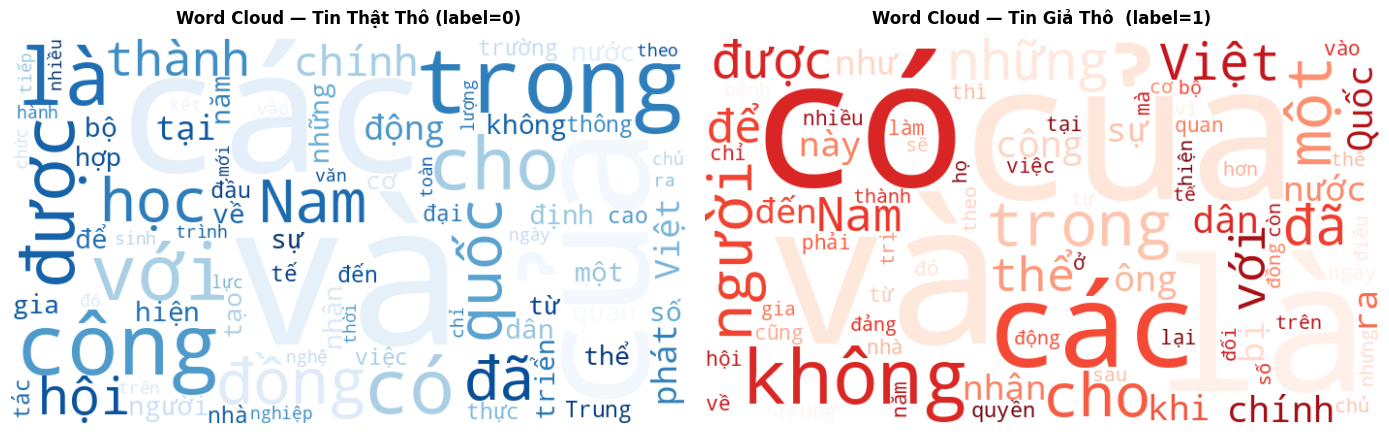

In [ ]:
text_true_raw = ' '.join(df.loc[df["is_fake"] == False, "content"].dropna())
text_fake_raw = ' '.join(df.loc[df["is_fake"] == True,  "content"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, title, colormap in [
    (axes[0], text_true_raw, "Word Cloud — Tin Thật Thô (label=0)", "Blues"),
    (axes[1], text_fake_raw, "Word Cloud — Tin Giả Thô  (label=1)", "Reds"),
]:
    try:
        wc = WordCloud(
            width=700, height=400,
            background_color="white",
            colormap=colormap,
            max_words=80,
            collocations=False,
            random_state=RANDOM_SEED
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    except Exception as e:
        ax.text(0.5, 0.5, f"Không tạo được word cloud\n({e})",
                ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("viz_raw_04_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3.5 Top-N Từ Phổ Biến Nhất Theo Nhãn (Thô)

Biểu đồ tần suất từ trên dữ liệu **thô** hỗ trợ phát hiện sớm các từ có tần suất cực cao tập trung vào một nhãn, dấu hiệu tiềm ẩn của **data leakage theo nguồn** (source-based leakage). Phân tích này được lặp lại ở Phần 5.4 sau tiền xử lý để so sánh hiệu quả làm sạch.


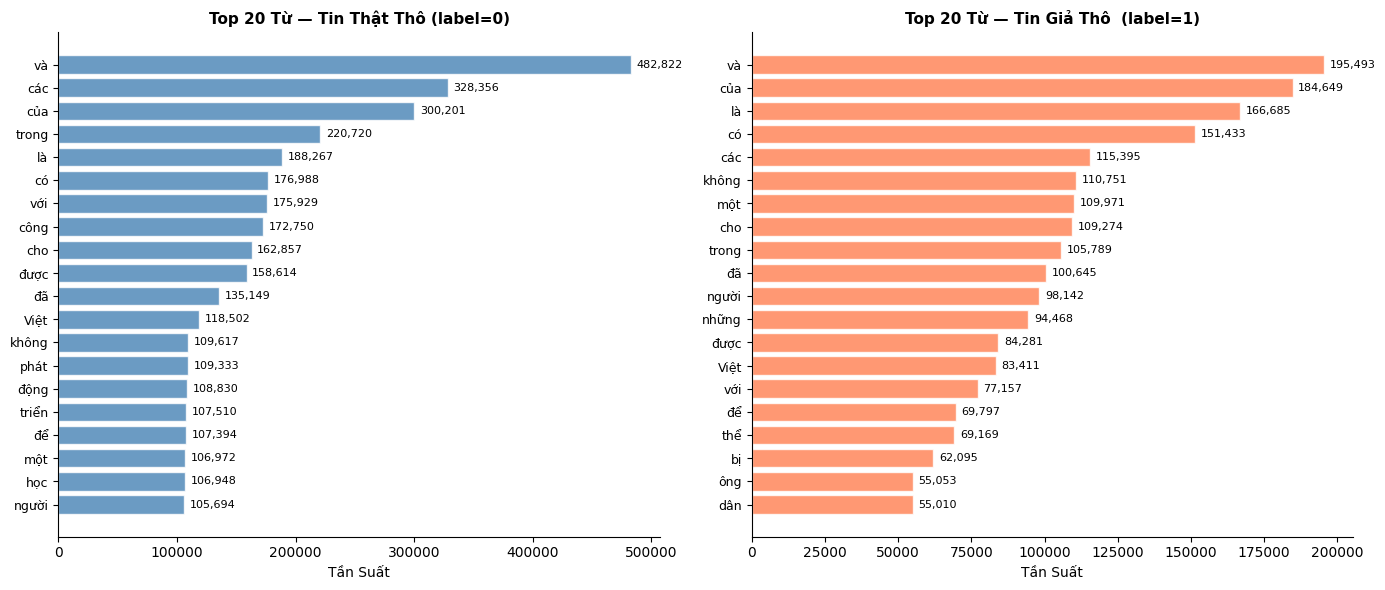

In [ ]:
N = 20

def top_n_words(texts, n: int = 20):
    """Trả về N từ xuất hiện nhiều nhất trong danh sách văn bản."""
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.split())
    return counter.most_common(n)

top_true_raw = top_n_words(df.loc[df["is_fake"] == False, "content"], N)
top_fake_raw = top_n_words(df.loc[df["is_fake"] == True,  "content"], N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top_words, title, color in [
    (axes[0], top_true_raw, f"Top {N} Từ — Tin Thật Thô (label=0)", "steelblue"),
    (axes[1], top_fake_raw, f"Top {N} Từ — Tin Giả Thô  (label=1)", "coral"),
]:
    words, counts = zip(*top_words)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Tần Suất")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + counts[0] * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{cnt:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("viz_raw_05_top_words.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Phần 3 — Tiền Xử Lý Văn Bản

Pipeline tiền xử lý chuyển văn bản tiếng Việt thô thành định dạng token hóa, chuẩn hóa, phù hợp cho các thuật toán học máy.

| Bước | Thao tác | Mục đích |
|------|----------|----------|
| 3.1 | Định nghĩa pipeline làm sạch văn bản | Chuẩn hóa Unicode, xóa nhiễu (URL, HTML, timestamp, ký tự đặc biệt), tách từ |
| 3.2 | Loại từ dừng | Xóa các từ thường xuyên không mang thông tin phân biệt nhãn |
| 3.3 | Lọc độ dài cuối & phân tích outlier | Đảm bảo ngưỡng chất lượng tối thiểu và phát hiện bản ghi cực dài |
| 3.4 | Tóm tắt thống kê sau tiền xử lý | Báo cáo trạng thái bộ dữ liệu trước khi chuyển sang EDA |


### 3.1 Định Nghĩa Pipeline Làm Sạch Văn Bản

Pipeline làm sạch gồm **10 bước tuần tự**, xử lý các vấn đề đặc thù của văn bản tiếng Việt thu thập tự động:

| Bước | Thao tác |
|------|----------|
| 1 | Chuẩn hóa Unicode về dạng NFC (thống nhất biểu diễn tổ hợp dấu) |
| 2 | Chuyển chữ thường |
| 3 | Xóa URL đầy đủ (`http://`, `www.`) |
| 4 | Xóa thẻ HTML |
| 5 | Xóa timestamp dạng `dd/mm/yyyy` và `yyyy-mm-dd` (trước tokenize) |
| 6 | Xóa ký tự đặc biệt (giữ chữ Việt, chữ số, khoảng trắng) |
| 7 | Tách từ tiếng Việt bằng ViTokenizer |
| 8 | Xóa URL fragment còn sót sau ViTokenizer (hex hash, dạng `word__word`) |
| 9 | Xóa timestamp dạng `dd mm yyyy` xuất hiện sau tokenize |
| 10 | Xóa token số đơn lẻ 1–2 chữ số và token Latin đơn ký tự |

> **Lưu ý:** Bước chuẩn hóa Unicode NFC (Bước 1) là bước quan trọng nhất đối với văn bản tiếng Việt, vì cùng một ký tự có dấu có thể được mã hóa theo hai cách khác nhau (precomposed và decomposed), dẫn đến việc tách từ và so sánh chuỗi bị sai.


In [ ]:
# ── Các hàm phụ trợ ────────────────────────────────────────────────────────

def remove_timestamps(text: str) -> str:
    """Xóa timestamp dạng 'dd mm yyyy' hoặc 'yyyy mm dd' còn sót sau tokenize."""
    text = re.sub(r'\b\d{1,2}\s+\d{1,2}\s+\d{4}\b', ' ', text)
    text = re.sub(r'\b\d{4}\s+\d{1,2}\s+\d{1,2}\b', ' ', text)
    return text


def remove_url_artifacts(text: str) -> str:
    """Xóa fragment URL còn sót sau ViTokenizer (hash hex, pattern word__word)."""
    text = re.sub(r'\b[a-f0-9]{7,}\b', ' ', text)           # hex hash ID
    text = re.sub(r'\b\w+__\w+\b', ' ', text)               # dạng word__word
    text = re.sub(
        r'\b(?:http|https|www|html|php|asp|jpg|jpeg|png|gif|mp4|videoinfo)\b',
        ' ', text, flags=re.I
    )
    return text


def remove_solo_numbers(text: str) -> str:
    """Xóa token số đơn lẻ 1-2 chữ số; giữ lại năm (4 chữ số) và số lớn (≥ 3 chữ số).

    Xử lý trước số có dấu phân cách ngàn (ví dụ: '290,000' → '290000')
    để tránh token '000' vô nghĩa sau khi tách.
    """
    # Xóa dấu phân cách ngàn để giữ nguyên giá trị số
    text = re.sub(r'\b(\d{1,3})(?:[,.](?=\d{3}))(\d{3}(?:[,.]\d{3})*)\b',
                  lambda m: re.sub(r'[,.]', '', m.group(0)), text)
    tokens = text.split()
    filtered = []
    for t in tokens:
        if t == '000':                                    # artifact vô nghĩa
            continue
        if not t.isdigit():                               # không phải số thuần
            filtered.append(t)
        elif len(t) == 4 and 1900 <= int(t) <= 2099:     # giữ năm
            filtered.append(t)
        elif len(t) >= 3:                                 # giữ số lớn có nghĩa
            filtered.append(t)
        # loại bỏ số 1–2 chữ số đứng một mình
    return ' '.join(filtered)


def remove_short_noise(text: str) -> str:
    """Xóa token Latin đơn ký tự (nhiễu không mang nghĩa)."""
    return ' '.join(
        t for t in text.split()
        if not (len(t) == 1 and t.isascii() and t.isalpha())
    )


def clean_text(text: str) -> str:
    """Pipeline làm sạch văn bản tiếng Việt — 10 bước tuần tự.

    Bước 1 : Chuẩn hóa Unicode NFC (thống nhất biểu diễn dấu tiếng Việt)
    Bước 2 : Chuyển chữ thường
    Bước 3 : Xóa URL đầy đủ
    Bước 4 : Xóa thẻ HTML
    Bước 5 : Xóa timestamp dạng dd/mm/yyyy và yyyy-mm-dd (trước tokenize)
    Bước 6 : Xóa ký tự đặc biệt (giữ chữ Việt, chữ số, khoảng trắng, gạch dưới)
    Bước 7 : Tách từ tiếng Việt bằng ViTokenizer
    Bước 8 : Xóa URL fragment còn sót sau ViTokenizer
    Bước 9 : Xóa timestamp dạng 'dd mm yyyy' (sau tokenize)
    Bước 10: Xóa token số đơn lẻ, token Latin đơn ký tự & chuẩn hóa khoảng trắng
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text = unicodedata.normalize('NFC', text)              # 1 — quan trọng với TV
    text = text.lower()                                    # 2
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # 3
    text = re.sub(r'<[^>]+>', ' ', text)                   # 4
    text = re.sub(r'\b\d{1,2}/\d{1,2}/\d{4}\b', ' ', text)  # 5a
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' ', text)      # 5b
    text = regex.sub(r'[^\p{L}\d\s_]', ' ', text)      # 6
    text = ViTokenizer.tokenize(text)                      # 7
    text = remove_url_artifacts(text)                      # 8
    text = remove_timestamps(text)                         # 9
    text = remove_solo_numbers(text)                       # 10
    text = remove_short_noise(text)                        # 10 (tiếp)

    return re.sub(r'\s+', ' ', text).strip()


print("Pipeline làm sạch văn bản (10 bước) đã sẵn sàng.")


Pipeline làm sạch văn bản đã sẵn sàng.


In [ ]:
def combine_text(row) -> str:
    """Gộp title + content; bỏ qua title nếu đã nằm trong content (tránh trùng lặp)."""
    title   = str(row["title"]).strip()
    content = str(row["content"]).strip()
    if not title:
        return content
    if not content:
        return title
    if title.lower() in content.lower():
        return content
    return title + " " + content


df["total_text"] = df.apply(combine_text, axis=1)

print("Đang làm sạch văn bản bằng parallel_apply (tận dụng đa nhân CPU)...")
df["text_cleaned"] = df["total_text"].parallel_apply(clean_text)
df.drop(columns=["total_text"], inplace=True)

print("\nHoàn tất!")
print(f"\nMẫu text_cleaned (50 token đầu):")
print(' '.join(df['text_cleaned'].iloc[0].split()[:50]))


Đang làm sạch văn bản (có thể mất vài phút)...
Hoàn tất!

Mẫu text_cleaned (50 token đầu):
mỗi năm trên toàn_cầu có triệu người mắc cúm mùa nặng nhiều ca tử_vong vì biến_chứng nghiêm_trọng ngày theo thống_kê từ tổ_chức y_tế thế_giới mỗi năm trên toàn_cầu có khoảng đến triệu người mắc bệnh cúm mùa nặng trong đó khoảng 290 đến 650 người tử_vong do các biến_chứng nghiêm_trọng


### 3.2 Loại Bỏ Từ Dừng

Tải danh sách từ dừng tiếng Việt từ kho `stopwords/vietnamese-stopwords` (GitHub). Kết quả được cache cục bộ vào file `vietnamese_stopwords.txt` để đảm bảo tính tái lập khi không có kết nối mạng.

Danh sách từ dừng được xây dựng với cả hai dạng: khoảng trắng (`bởi vì`) và gạch dưới (`bởi_vì`) để khớp chính xác với đầu ra của ViTokenizer. Bước loại từ dừng cũng được thực thi song song bằng `parallel_apply`.


In [ ]:
RAW_URL        = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
STOPWORD_CACHE = Path("vietnamese_stopwords.txt")

try:
    resp = requests.get(RAW_URL, timeout=10)
    resp.raise_for_status()
    STOPWORD_CACHE.write_text(resp.text, encoding="utf-8")
    stopword_raw = resp.text
    print("Đã tải danh sách từ dừng từ GitHub.")
except Exception as e:
    if STOPWORD_CACHE.exists():
        stopword_raw = STOPWORD_CACHE.read_text(encoding="utf-8")
        print(f"Lỗi mạng ({e}) — sử dụng cache cục bộ.")
    else:
        raise RuntimeError("Không tải được từ dừng và không có cache.") from e

# Xây dựng tập từ dừng (cả dạng khoảng trắng và gạch dưới)
stopwords = set()
for line in stopword_raw.splitlines():
    w = line.strip()
    if w:
        stopwords.add(w)
        stopwords.add(w.replace(" ", "_"))

print(f"Kích thước tập từ dừng: {len(stopwords)} mục")


def remove_stopwords(text: str) -> str:
    """Xóa các token thuộc danh sách từ dừng khỏi văn bản đã tách từ."""
    if not isinstance(text, str) or not text.strip():
        return ''
    tokens   = text.split()
    filtered = [t for t in tokens if t not in stopwords]
    return ' '.join(filtered) if filtered else text


df_clean = df.copy()
print("Đang loại từ dừng bằng parallel_apply...")
df_clean["text_final"] = df_clean["text_cleaned"].parallel_apply(remove_stopwords)

mean_before = df_clean["text_cleaned"].str.split().str.len().mean()
mean_after  = df_clean["text_final"].str.split().str.len().mean()
print(f"\nSố token trung bình — Trước loại từ dừng : {mean_before:.1f}")
print(f"Số token trung bình — Sau loại từ dừng   : {mean_after:.1f}  (giảm {(1 - mean_after/mean_before)*100:.1f}%)")


Đã tải danh sách từ dừng từ GitHub.
Kích thước tập từ dừng: 3513 mục

Số token trung bình — Trước loại từ dừng : 581.1
Số token trung bình — Sau loại từ dừng   : 327.9  (giảm 43.6%)


### 3.3 Lọc Độ Dài Cuối Cùng & Phân Tích Outlier

Áp dụng lần lọc độ dài cuối cùng trên `text_final` (≥ 30 token sau loại từ dừng) nhằm loại bỏ các bản ghi có nội dung quá ngắn, không cung cấp đủ thông tin để mô hình học máy phân biệt nhãn.

Tiếp theo, phân tích outlier bằng phương pháp **Tukey Fence mở rộng** (Q3 + 3 × IQR) để phát hiện các bản ghi cực dài có thể ảnh hưởng tiêu cực đến hiệu suất của các mô hình nhạy cảm với độ dài đầu vào (Logistic Regression, SVM tuyến tính). Kết quả phân tích được sử dụng để đề xuất ngưỡng cắt (truncate) khi huấn luyện — không xóa bản ghi.


In [ ]:
before_post = len(df_clean)
df_clean = df_clean[
    df_clean["text_final"].str.split().str.len() >= 30
].reset_index(drop=True)

print(f"Sau lọc cuối: đã loại {before_post - len(df_clean)} bản ghi → còn lại {len(df_clean):,}")
print("\nPhân phối nhãn cuối cùng:")
print(df_clean["is_fake"].value_counts())
print(f"\nTỷ lệ mất cân bằng lớp: {df_clean['is_fake'].value_counts().max() / df_clean['is_fake'].value_counts().min():.2f}x")

# Phân tích outlier độ dài (Tukey Fence mở rộng)
tl      = df_clean["text_final"].str.split().str.len()
q1, q3  = tl.quantile(0.25), tl.quantile(0.75)
iqr     = q3 - q1
upper_fence = q3 + 3 * iqr
outliers    = (tl > upper_fence).sum()

print(f"\n=== Phân Tích Outlier Độ Dài ===")
print(f"  Q1 = {q1:.0f}  |  Q3 = {q3:.0f}  |  IQR = {iqr:.0f}")
print(f"  Ngưỡng trên (Q3 + 3×IQR) : {upper_fence:.0f} token")
print(f"  Số bản ghi outlier        : {outliers} ({outliers/len(df_clean)*100:.1f}%)")
print(f"  Max = {tl.max()} token   |  Median = {tl.median():.0f} token")
if outliers > 0:
    print(f"  → Khi huấn luyện, cân nhắc truncate text_final tại {int(upper_fence)} token")
    print(f"    để giảm ảnh hưởng của outlier đến các mô hình tuyến tính (LogReg, SVM).")


Sau lọc cuối: đã loại 702 bản ghi → còn lại 54,244

Phân phối nhãn cuối cùng:
is_fake
False    38978
True     15266
Name: count, dtype: int64

Tỷ lệ mất cân bằng lớp: 2.55x

=== Phân Tích Outlier Độ Dài ===
  Q1 = 169  |  Q3 = 420  |  IQR = 251
  Ngưỡng trên (Q3 + 3×IQR) : 1173 token
  Số bản ghi outlier        : 666 (1.2%)
  Max = 19942 token   |  Median = 274 token
  → Khi huấn luyện, cân nhắc truncate text_final tại 1173 token
    để giảm ảnh hưởng của outlier đến các mô hình tuyến tính (LogReg, SVM).


### 3.4 Tóm Tắt Thống Kê Dữ Liệu Sau Tiền Xử Lý

Sau các bước làm sạch và tiền xử lý văn bản, bộ dữ liệu `df_clean` hiện đã sẵn sàng cho giai đoạn phân tích khám phá (EDA) và huấn luyện mô hình. Báo cáo dưới đây trình bày các thuộc tính thống kê chính của bộ dữ liệu sau xử lý, bao gồm phân phối nhãn, thống kê độ dài token, và kết quả kiểm định Mann-Whitney U so sánh phân phối độ dài giữa hai lớp.


In [ ]:
from scipy import stats

content_lengths_clean = df_clean["text_final"].str.split().str.len()
# Use 'is_fake' column as 'label' is created later in the notebook
label_counts_clean    = df_clean["is_fake"].value_counts()
n_real_clean          = label_counts_clean.get(False, 0) # Map False to 0
n_fake_clean          = label_counts_clean.get(True,  0)  # Map True to 1
imbalance_ratio_clean = max(n_real_clean, n_fake_clean) / min(n_real_clean, n_fake_clean)

# Use 'is_fake' column for filtering
len_real_clean = df_clean.loc[df_clean["is_fake"] == False, "text_final"].str.split().str.len()
len_fake_clean = df_clean.loc[df_clean["is_fake"] == True,  "text_final"].str.split().str.len()
u_stat_clean, p_val_clean = stats.mannwhitneyu(len_real_clean, len_fake_clean, alternative="two-sided")
r_effect_clean = 1 - 2 * u_stat_clean / (len(len_real_clean) * len(len_fake_clean))

print("=" * 58)
print("       THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU SAU TIỀN XỬ LÝ")
print("=" * 58)
print(f"  Tổng bản ghi          : {len(df_clean):,}")
print(f"  Tin thật (label=0)    : {n_real_clean:,}  ({n_real_clean/len(df_clean)*100:.1f}%)")
print(f"  Tin giả  (label=1)    : {n_fake_clean:,}  ({n_fake_clean/len(df_clean)*100:.1f}%)")
print(f"  Tỷ lệ mất cân bằng    : {imbalance_ratio_clean:.2f}x")
print("-" * 58)
print(f"  Độ dài text_final (token) — Toàn bộ:")
print(f"    Mean={content_lengths_clean.mean():.1f}  |  Median={content_lengths_clean.median():.0f}")
print(f"    Min={content_lengths_clean.min()}         |  Max={content_lengths_clean.max()}")
print(f"  Độ dài text_final (token) — Theo nhãn:")
print(f"    Tin thật : mean={len_real_clean.mean():.1f}, median={len_real_clean.median():.0f}")
print(f"    Tin giả  : mean={len_fake_clean.mean():.1f}, median={len_fake_clean.median():.0f}")
print("-" * 58)
pstar_clean = '***' if p_val_clean < 0.001 else '**' if p_val_clean < 0.01 else '*' if p_val_clean < 0.05 else 'ns'
print(f"  Mann-Whitney U test   : p = {p_val_clean:.2e}  ({pstar_clean})")
print(f"  Rank-biserial r       : {abs(r_effect_clean):.4f}  ",
      "(Lớn)" if abs(r_effect_clean) >= 0.5 else "(Vừa)" if abs(r_effect_clean) >= 0.3 else "(Nhỏ)")
print("=" * 58)

       THỐNG KÊ MÔ TẢ BỘ DỮ LIỆU SAU TIỀN XỬ LÝ
  Tổng bản ghi          : 54,244
  Tin thật (label=0)    : 38,978  (71.9%)
  Tin giả  (label=1)    : 15,266  (28.1%)
  Tỷ lệ mất cân bằng    : 2.55x
----------------------------------------------------------
  Độ dài text_final (token) — Toàn bộ:
    Mean=331.9  |  Median=274
    Min=30         |  Max=19942
  Độ dài text_final (token) — Theo nhãn:
    Tin thật : mean=311.8, median=263
    Tin giả  : mean=383.2, median=301
----------------------------------------------------------
  Mann-Whitney U test   : p = 2.24e-77  (***)
  Rank-biserial r       : 0.1026   (Nhỏ)


---
## Phần 4 — Mã Hóa Nhãn

Chuyển đổi cột boolean `is_fake` sang nhãn số nguyên `label` theo quy ước nhị phân chuẩn:

| Giá trị `is_fake` | Nhãn `label` | Ý nghĩa |
|-------------------|-------------|---------|
| `False` | `0` | Tin thật |
| `True`  | `1` | Tin giả  |


In [ ]:
df_clean["label"] = df_clean["is_fake"].astype(int)

print("Mã hóa: False (tin thật) → 0  |  True (tin giả) → 1")
print("\nPhân phối nhãn sau mã hóa:")
print(df_clean["label"].value_counts().rename({0: "Tin thật (0)", 1: "Tin giả (1)"}))


Mã hóa: False (tin thật) → 0  |  True (tin giả) → 1

Phân phối nhãn sau mã hóa:
label
Tin thật (0)    38978
Tin giả (1)     15266
Name: count, dtype: int64


---
## Phần 5 — Phân Tích Khám Phá Dữ Liệu (EDA)

Phần này trực quan hóa bộ dữ liệu sau tiền xử lý qua **5 góc nhìn** bổ sung cho nhau:

| Mục | Biểu đồ | Mục đích chính |
|-----|---------|----------------|
| 5.1 | Phân phối lớp | Đánh giá mức độ mất cân bằng nhãn |
| 5.2 | Phân phối độ dài | So sánh độ dài nội dung giữa hai lớp |
| 5.3 | Word Cloud | Nhận diện từ đặc trưng, phát hiện data leakage tiềm ẩn |
| 5.4 | Top-N từ phổ biến | Kiểm tra data leakage theo tần suất |
| 5.5 | Boxplot độ dài | Phân tích phân phối và outlier trực quan |


### 5.1 Phân Phối Lớp


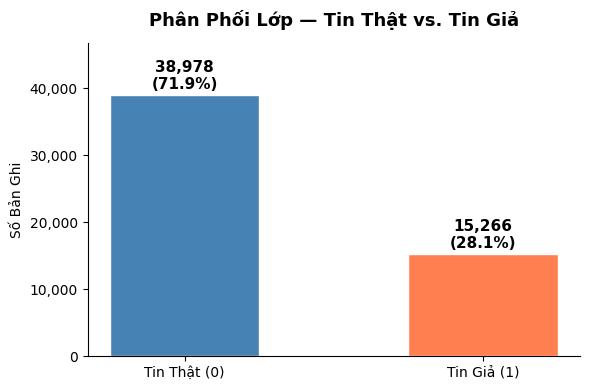

In [ ]:
label_counts = df_clean["label"].value_counts().sort_index()
labels       = ["Tin Thật (0)", "Tin Giả (1)"]
colors       = ["steelblue", "coral"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, label_counts.values, color=colors, edgecolor="white", width=0.5)

for bar, count in zip(bars, label_counts.values):
    pct = count / label_counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + label_counts.max() * 0.01,
        f"{count:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )

ax.set_title("Phân Phối Lớp — Tin Thật vs. Tin Giả", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Số Bản Ghi")
ax.set_ylim(0, label_counts.max() * 1.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_01_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.2 Phân Phối Độ Dài Nội Dung

Histogram so sánh phân phối số token của hai lớp. Đường nét đứt đánh dấu giá trị trung vị. Trục x được giới hạn tại phân vị 99% để loại trừ ảnh hưởng của outlier cực đại.


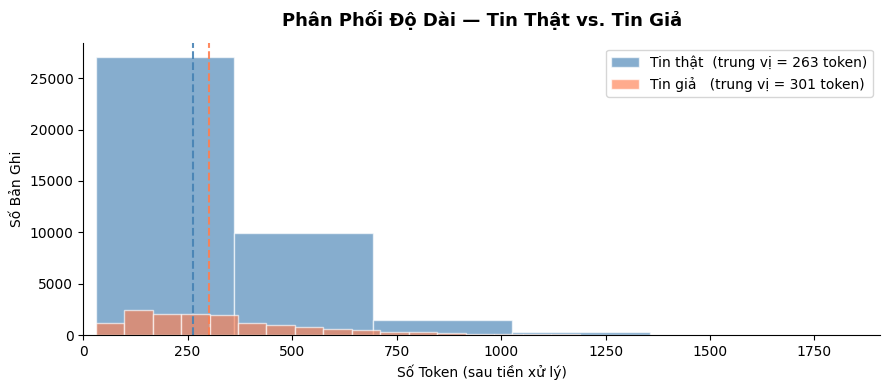

In [ ]:
len_real = df_clean.loc[df_clean["label"] == 0, "text_final"].str.split().str.len()
len_fake = df_clean.loc[df_clean["label"] == 1, "text_final"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(len_real, bins=60, alpha=0.65, color="steelblue", edgecolor="white",
        label=f"Tin thật  (trung vị = {len_real.median():.0f} token)")
ax.hist(len_fake, bins=60, alpha=0.65, color="coral",     edgecolor="white",
        label=f"Tin giả   (trung vị = {len_fake.median():.0f} token)")

ax.axvline(len_real.median(), color="steelblue", linestyle="--", linewidth=1.5, alpha=0.9)
ax.axvline(len_fake.median(), color="coral",     linestyle="--", linewidth=1.5, alpha=0.9)

ax.set_title("Phân Phối Độ Dài — Tin Thật vs. Tin Giả", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Số Token (sau tiền xử lý)")
ax.set_ylabel("Số Bản Ghi")
ax.legend(fontsize=10)
ax.set_xlim(0, max(len_real.quantile(0.99), len_fake.quantile(0.99)) * 1.05)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_02_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.3 Word Cloud Theo Nhãn

Word cloud trực quan hóa các từ đặc trưng cho mỗi nhãn. So sánh hai cloud giúp phát hiện **data leakage tiềm ẩn** — khi một từ chủ đề (domain-specific) xuất hiện gần như chỉ trong một lớp.


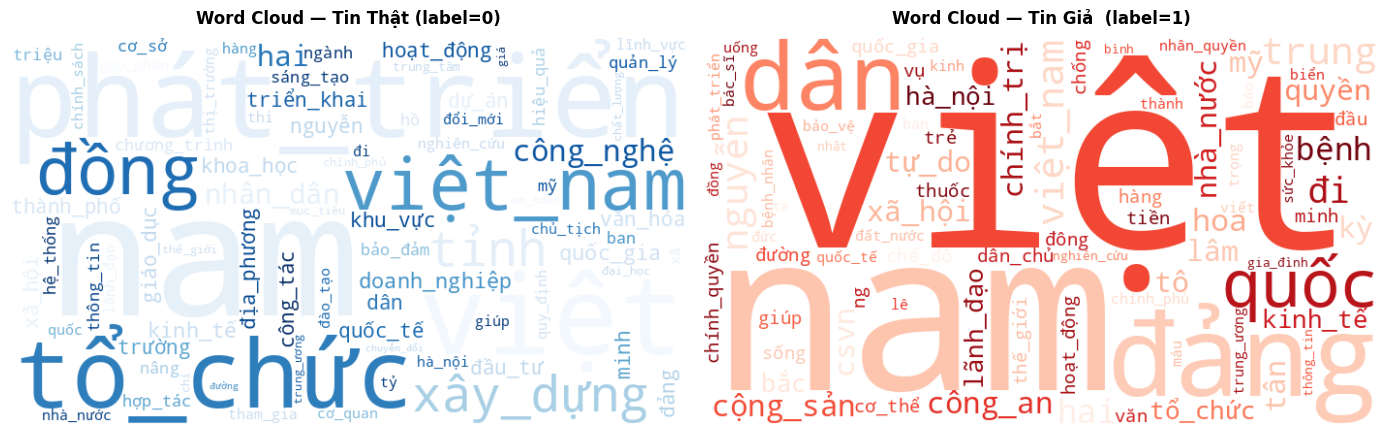

In [ ]:
text_true = ' '.join(df_clean.loc[df_clean["label"] == 0, "text_final"].dropna())
text_fake = ' '.join(df_clean.loc[df_clean["label"] == 1, "text_final"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, text, title, colormap in [
    (axes[0], text_true, "Word Cloud — Tin Thật (label=0)", "Blues"),
    (axes[1], text_fake, "Word Cloud — Tin Giả  (label=1)", "Reds"),
]:
    try:
        wc = WordCloud(
            width=700, height=400,
            background_color="white",
            colormap=colormap,
            max_words=80,
            collocations=False,
            random_state=RANDOM_SEED
        ).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    except Exception as e:
        ax.text(0.5, 0.5, f"Không tạo được word cloud\n({e})",
                ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)

plt.tight_layout()
plt.savefig("viz_03_wordcloud.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.4 Top-N Từ Phổ Biến Nhất Theo Nhãn

Nếu một từ xuất hiện với tần suất cực cao trong tin giả nhưng hiếm trong tin thật (hoặc ngược lại), mô hình có thể học **shortcut theo domain** thay vì các đặc trưng ngôn ngữ thực sự. Biểu đồ này hỗ trợ phát hiện vấn đề đó.


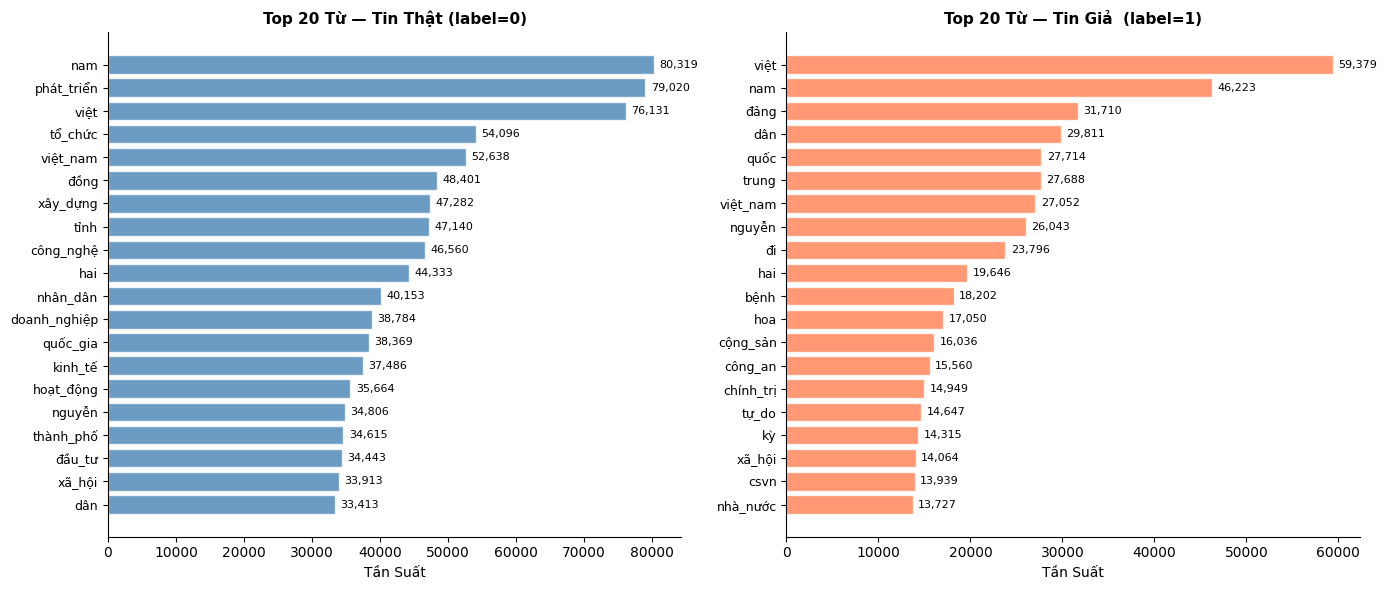

In [ ]:
N = 20

def top_n_words(texts, n: int = 20):
    """Trả về N từ xuất hiện nhiều nhất trong danh sách văn bản."""
    counter = Counter()
    for text in texts:
        if isinstance(text, str):
            counter.update(text.split())
    return counter.most_common(n)


top_true = top_n_words(df_clean.loc[df_clean["label"] == 0, "text_final"], N)
top_fake = top_n_words(df_clean.loc[df_clean["label"] == 1, "text_final"], N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top_words, title, color in [
    (axes[0], top_true, f"Top {N} Từ — Tin Thật (label=0)", "steelblue"),
    (axes[1], top_fake, f"Top {N} Từ — Tin Giả  (label=1)", "coral"),
]:
    words, counts = zip(*top_words)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.8, edgecolor="white")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Tần Suất")
    ax.spines[["top", "right"]].set_visible(False)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + counts[0] * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{cnt:,}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("viz_04_top_words.png", dpi=150, bbox_inches="tight")
plt.show()


### 5.5 Boxplot Độ Dài — Phân Tích Phân Phối & Outlier

Boxplot cung cấp góc nhìn bổ sung cho histogram ở Mục 5.2: so sánh trung vị, tứ phân vị, và phạm vi outlier giữa hai lớp nhãn.


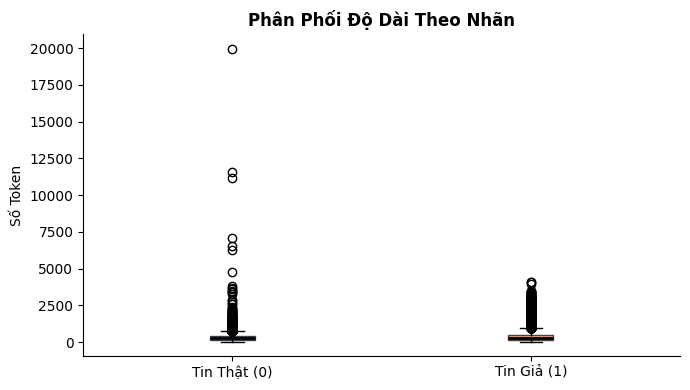

In [ ]:
df_clean["token_count"] = df_clean["text_final"].str.split().str.len()

fig, ax = plt.subplots(figsize=(7, 4))

data_true = df_clean.loc[df_clean["label"] == 0, "token_count"]
data_fake = df_clean.loc[df_clean["label"] == 1, "token_count"]

bp = ax.boxplot(
    [data_true, data_fake],
    labels=["Tin Thật (0)", "Tin Giả (1)"],
    patch_artist=True,
    notch=False,
    medianprops=dict(color="black", linewidth=2)
)
bp["boxes"][0].set_facecolor("steelblue"); bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("coral");     bp["boxes"][1].set_alpha(0.7)

ax.set_title("Phân Phối Độ Dài Theo Nhãn", fontsize=12, fontweight="bold")
ax.set_ylabel("Số Token")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("viz_05_boxplot_length.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Phần 6 — Xuất Bộ Dữ Liệu Cuối Cùng

Bộ dữ liệu được xuất thành ba tệp CSV (dấu phân cách `;` để tương thích với Excel tiếng Việt):

| Tệp | Nội dung |
|-----|----------|
| `fakenews_cleaned_full.csv` | Toàn bộ bộ dữ liệu |
| `fakenews_train.csv` | 80% tập huấn luyện (phân tầng theo nhãn) |
| `fakenews_test.csv` | 20% tập kiểm tra (phân tầng theo nhãn) |


### 6.1 Kiểm Tra Chất Lượng Trước Khi Xuất


In [ ]:
EXPORT_COLS = ["title", "content", "text_final", "label"]
df_export   = df_clean[EXPORT_COLS].copy()

print("=" * 58)
print("         QUALITY REPORT TRƯỚC KHI XUẤT")
print("=" * 58)
print(f"  Tổng bản ghi          : {len(df_export):,}")
print(f"  Giá trị null          : {df_export.isnull().sum().sum()}")
print(f"  Trùng lặp content     : {df_export.duplicated(subset=['content']).sum()}")
print(f"  Trùng lặp title       : {df_export.duplicated(subset=['title']).sum()}")
print(f"  Trùng lặp text_final  : {df_export.duplicated(subset=['text_final']).sum()}")
print("-" * 58)
print("  Phân phối nhãn:")
vc = df_export["label"].value_counts()
for lbl, cnt in vc.items():
    name = "Tin thật (0)" if lbl == 0 else "Tin giả  (1)"
    print(f"    {name}: {cnt:,}  ({cnt/len(df_export)*100:.1f}%)")
print("-" * 58)
tl = df_export["text_final"].str.split().str.len()
print(f"  Thống kê số token text_final:")
print(f"    Mean={tl.mean():.1f}  |  Median={tl.median():.0f}  |  Min={tl.min()}  |  Max={tl.max()}")
print("=" * 58)

df_export.head(3)


         QUALITY REPORT TRƯỚC KHI XUẤT
  Tổng bản ghi          : 54,244
  Giá trị null          : 0
  Trùng lặp content     : 0
  Trùng lặp title       : 123
  Trùng lặp text_final  : 6
----------------------------------------------------------
  Phân phối nhãn:
    Tin thật (0): 38,978  (71.9%)
    Tin giả  (1): 15,266  (28.1%)
----------------------------------------------------------
  Thống kê số token text_final:
    Mean=331.9  |  Median=274  |  Min=30  |  Max=19942


,title,content,text_final,label
0,Mỗi năm trên toàn cầu có 3-5 triệu người mắc c...,Ngày 24/11/2024\nTheo thống kê từ Tổ chức Y tế...,toàn_cầu triệu mắc cúm mùa ca tử_vong biến_chứ...,1
1,"Bác sĩ kê toa thực phẩm chức năng, bệnh nhân k...","Ngày 23/11/2024\nChị Huyền, 37 tuổi, đến bệnh ...",bác_sĩ kê toa thực_phẩm chức_năng bệnh_nhân tá...,1
2,Dịch sở tại TP Hồ Chí Minh tăng mạnh trong tuầ...,Ngày 22/11/2024\nTrong tuần qua (tính đến ngày...,dịch sở_tại tp hồ chí minh tuần tuần tình_hình...,1


### 6.2 Phân Chia Train/Test & Xuất CSV

Phân chia theo phương pháp **stratified split** (80/20) để đảm bảo tỷ lệ nhãn được giữ nguyên trong cả hai tập.


In [ ]:
train_df, test_df = train_test_split(
    df_export,
    test_size=0.2,
    stratify=df_export["label"],
    random_state=RANDOM_SEED,
)

# Xuất CSV với dấu phân cách ';' — tương thích Excel (chọn delimiter Semicolon khi mở)
df_export.to_csv("fakenews_cleaned_full.csv", index=False, encoding="utf-8-sig", sep=";")
train_df.to_csv("fakenews_train.csv",          index=False, encoding="utf-8-sig", sep=";")
test_df.to_csv("fakenews_test.csv",             index=False, encoding="utf-8-sig", sep=";")

print("=== Xuất hoàn tất ===")
print(f"  fakenews_cleaned_full.csv : {len(df_export):,} bản ghi")
print(f"  fakenews_train.csv        : {len(train_df):,} bản ghi  (80%)")
print(f"  fakenews_test.csv         : {len(test_df):,} bản ghi   (20%)")
print("\nPhân phối nhãn — Tập huấn luyện:")
print(train_df["label"].value_counts().rename({0: "Tin thật (0)", 1: "Tin giả (1)"}))
print("\nPhân phối nhãn — Tập kiểm tra:")
print(test_df["label"].value_counts().rename({0: "Tin thật (0)", 1: "Tin giả (1)"}))


=== Xuất hoàn tất ===
  fakenews_cleaned_full.csv : 54,244 bản ghi
  fakenews_train.csv        : 43,395 bản ghi  (80%)
  fakenews_test.csv         : 10,849 bản ghi   (20%)

Phân phối nhãn — Tập huấn luyện:
label
Tin thật (0)    31182
Tin giả (1)     12213
Name: count, dtype: int64

Phân phối nhãn — Tập kiểm tra:
label
Tin thật (0)    7796
Tin giả (1)     3053
Name: count, dtype: int64
